In [ ]:
!pip install scikit-image opencv-python-headless tensorflow scikit-learn seaborn matplotlib -q

import os, cv2, shutil, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from skimage.feature import local_binary_pattern, hog
from skimage import exposure
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import (ImageDataGenerator,
                                                   img_to_array, load_img)
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as K

print(" All libraries loaded!")

 All libraries loaded!


In [ ]:
for folder in ['dataset/LV_like', 'dataset/Other',
               'dataset_augmented/LV_like', 'dataset_augmented/Other',
               'results']:
    os.makedirs(folder, exist_ok=True)

print("Folders ready")

Folders ready


In [ ]:
from google.colab import files

print("Upload LV_like images:")
uploaded = files.upload()
for fname, data in uploaded.items():
    open(f'dataset/LV_like/{fname}', 'wb').write(data)
print(f" {len(uploaded)} LV images saved")

print("\nUpload Other skin images:")
uploaded2 = files.upload()
for fname, data in uploaded2.items():
    open(f'dataset/Other/{fname}', 'wb').write(data)
print(f" {len(uploaded2)} Other images saved")

Upload LV_like images:


Saving imag1.jpeg to imag1.jpeg
Saving imag2.jpeg to imag2.jpeg
Saving imag3.jpeg to imag3.jpeg
Saving imag4.jpeg to imag4.jpeg
Saving imag5.jpeg to imag5.jpeg
Saving imag6.png to imag6.png
Saving imag7.png to imag7.png
Saving imag8.jpeg to imag8.jpeg
Saving imag9.png to imag9.png
Saving imag10.png to imag10.png
Saving imag11.png to imag11.png
Saving imag12.png to imag12.png
Saving imag13.png to imag13.png
Saving imag14.png to imag14.png
Saving imag15.png to imag15.png
 15 LV images saved

Upload Other skin images:


Saving imag1.png to imag1.png
Saving imag2.png to imag2.png
Saving imag3.png to imag3.png
Saving imag4.png to imag4.png
Saving imag5.png to imag5.png
Saving imag6.png to imag6 (1).png
Saving imag7.png to imag7 (1).png
Saving imag8.png to imag8.png
 8 Other images saved


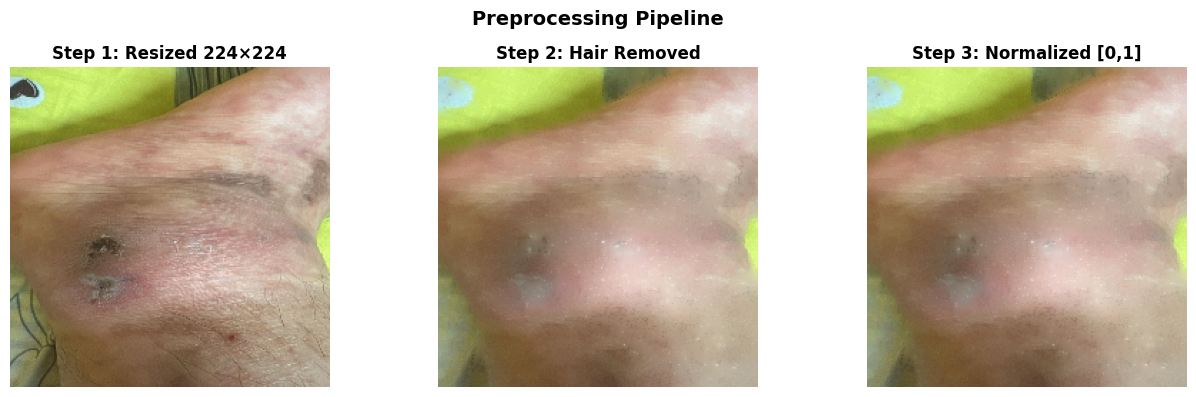

 Saved preprocessing.png


In [ ]:
IMG_SIZE = 224

def remove_hair(image):
    gray   = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    bhat   = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(bhat, 10, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(image, mask, 6, cv2.INPAINT_TELEA)

def preprocess(path):
    img = cv2.imread(path)
    if img is None:
        return None, None, None
    img   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img   = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    clean = cv2.cvtColor(remove_hair(cv2.cvtColor(img, cv2.COLOR_RGB2BGR)),
                         cv2.COLOR_BGR2RGB)
    norm  = clean.astype(np.float32) / 255.0
    return img, clean, norm

# Visualize preprocessing
lv_files = [f for f in os.listdir('dataset/LV_like')
            if f.lower().endswith(('.jpg','.jpeg','.png'))]

orig, clean, norm = preprocess(f'dataset/LV_like/{lv_files[0]}')
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Preprocessing Pipeline', fontsize=14, fontweight='bold')
for ax, im, title in zip(axes,
                          [orig, clean, norm],
                          ['Step 1: Resized 224×224',
                           'Step 2: Hair Removed',
                           'Step 3: Normalized [0,1]']):
    ax.imshow(im); ax.set_title(title, fontweight='bold'); ax.axis('off')
plt.tight_layout()
plt.savefig('results/preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved preprocessing.png")

In [ ]:
augmentor = ImageDataGenerator(
    rotation_range=30,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

def augment_class(src, dst, label, target=100):
    os.makedirs(dst, exist_ok=True)
    imgs = [f for f in os.listdir(src)
            if f.lower().endswith(('.jpg','.jpeg','.png'))]
    for f in imgs:
        shutil.copy(os.path.join(src, f), os.path.join(dst, f))
    count = len(imgs)
    while count < target:
        for f in imgs:
            if count >= target: break
            x = np.expand_dims(img_to_array(
                    load_img(os.path.join(src, f),
                             target_size=(IMG_SIZE, IMG_SIZE))), 0)
            for batch in augmentor.flow(x, batch_size=1,
                                        save_to_dir=dst,
                                        save_prefix=f'aug_{label}',
                                        save_format='jpg'):
                count += 1; break
    print(f"  {label}: {len(imgs)} → {count} images")
    return count

augment_class('dataset/LV_like', 'dataset_augmented/LV_like', 'LV')
augment_class('dataset/Other',   'dataset_augmented/Other',   'Other')
print(" Augmentation done")

  LV: 15 → 100 images
  Other: 8 → 100 images
 Augmentation done


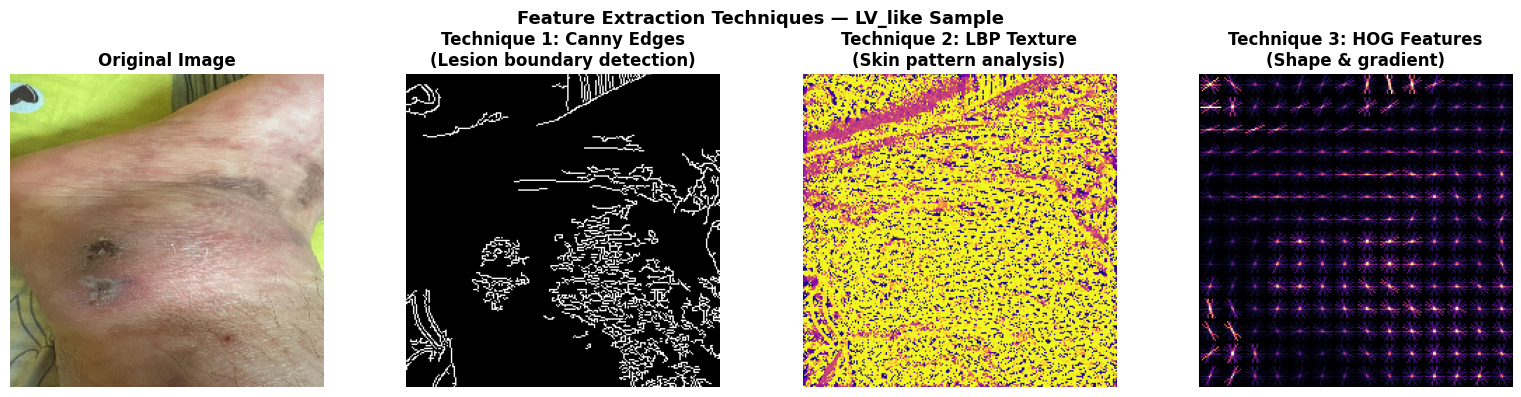

 Feature map saved for LV_like Sample


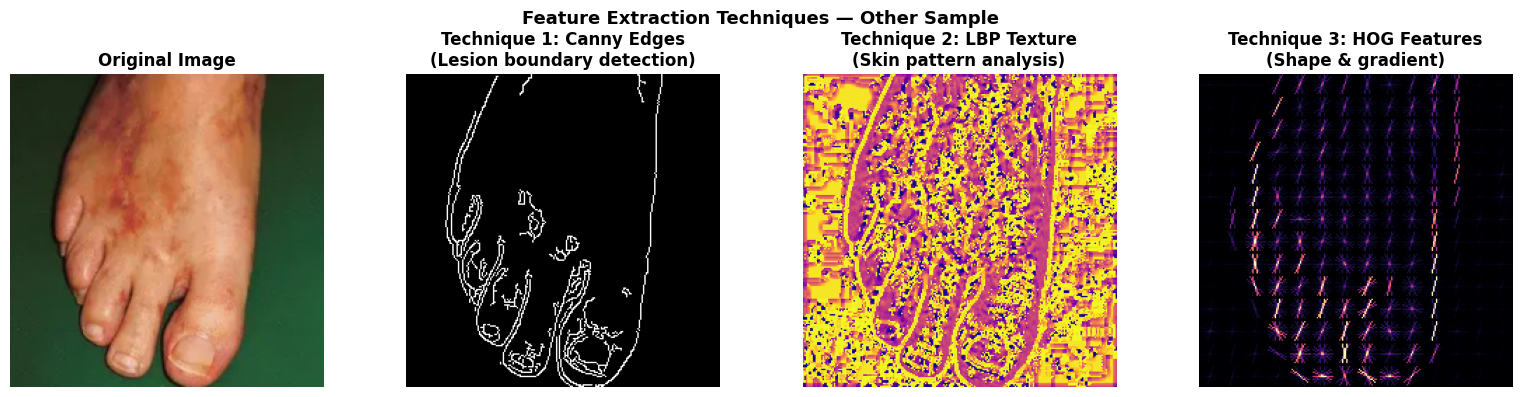

 Feature map saved for Other Sample


In [ ]:


def show_all_features(path, label):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Technique 1: Canny Edge Detection
    edges = cv2.Canny(gray, 50, 150)

    # Technique 2: LBP (Local Binary Pattern) — texture
    lbp     = local_binary_pattern(gray, 24, 3, method='uniform')
    lbp_vis = (lbp / lbp.max() * 255).astype(np.uint8)

    # Technique 3: HOG (Histogram of Oriented Gradients) — shape
    _, hog_img = hog(gray, orientations=9,
                     pixels_per_cell=(16, 16),
                     cells_per_block=(2, 2),
                     visualize=True)
    hog_vis = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f'Feature Extraction Techniques — {label}',
                 fontsize=13, fontweight='bold')
    axes[0].imshow(img);                      axes[0].set_title('Original Image',           fontweight='bold')
    axes[1].imshow(edges,   cmap='gray');     axes[1].set_title('Technique 1: Canny Edges\n(Lesion boundary detection)', fontweight='bold')
    axes[2].imshow(lbp_vis, cmap='plasma');   axes[2].set_title('Technique 2: LBP Texture\n(Skin pattern analysis)',     fontweight='bold')
    axes[3].imshow(hog_vis, cmap='magma');    axes[3].set_title('Technique 3: HOG Features\n(Shape & gradient)',         fontweight='bold')
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    safe = label.replace(' ', '_')
    plt.savefig(f'results/features_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f" Feature map saved for {label}")

lv_files    = [f for f in os.listdir('dataset/LV_like')
               if f.lower().endswith(('.jpg','.jpeg','.png'))]
other_files = [f for f in os.listdir('dataset/Other')
               if f.lower().endswith(('.jpg','.jpeg','.png'))]

show_all_features(f'dataset/LV_like/{lv_files[0]}',    'LV_like Sample')
show_all_features(f'dataset/Other/{other_files[0]}',   'Other Sample')

In [ ]:
CLASSES = ['LV_like', 'Other']

def load_dataset(base):
    X, y = [], []
    for idx, cls in enumerate(CLASSES):
        folder = os.path.join(base, cls)
        files  = [f for f in os.listdir(folder)
                  if f.lower().endswith(('.jpg','.jpeg','.png'))]
        print(f"  {cls}: {len(files)} images")
        for f in files:
            img = cv2.imread(os.path.join(folder, f))
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0
            X.append(img); y.append(idx)
    return np.array(X), np.array(y)

X, y = load_dataset('dataset_augmented')
print(f"\nTotal: {len(X)} images loaded")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

y_train_cat = to_categorical(y_train, 2)
y_val_cat   = to_categorical(y_val,   2)
print(f"Train: {len(X_train)}  |  Val: {len(X_val)}")

  LV_like: 98 images
  Other: 100 images

Total: 198 images loaded
Train: 168  |  Val: 30


In [ ]:
# Key changes to fix 100% overfitting:
# 1. Stronger dropout (0.6)
# 2. Higher L2 penalty
# 3. Smaller dense layer (64 only, no 128)
# 4. Label smoothing in loss

def build_model():
    base = MobileNetV2(input_shape=(224, 224, 3),
                       include_top=False, weights='imagenet')
    base.trainable = False  # freeze all base layers

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='relu',
               kernel_regularizer=tf.keras.regularizers.l2(0.05))(x)
    x = Dropout(0.6)(x)
    out = Dense(2, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    return model

model = build_model()
print(" Model built — anti-overfitting architecture")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
 Model built — anti-overfitting architecture


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,340,098 (8.93 MB)

 Trainable params: 82,114 (320.76 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-7, verbose=1)
]

print("Training Algorithm 1 (baseline fix)...")
history1 = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30, batch_size=16,
    callbacks=callbacks, verbose=1
)
print(f"Best val accuracy: {max(history1.history['val_accuracy'])*100:.1f}%")

Training Algorithm 1 (baseline fix)...
Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 550ms/step - accuracy: 0.5774 - loss: 7.0441 - val_accuracy: 0.6667 - val_loss: 6.6074 - learning_rate: 1.0000e-04
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 497ms/step - accuracy: 0.6429 - loss: 6.6136 - val_accuracy: 0.7667 - val_loss: 6.3953 - learning_rate: 1.0000e-04
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 502ms/step - accuracy: 0.5774 - loss: 6.5276 - val_accuracy: 0.8000 - val_loss: 6.2155 - learning_rate: 1.0000e-04
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 454ms/step - accuracy: 0.6905 - loss: 6.2560 - val_accuracy: 0.8667 - val_loss: 6.0527 - learning_rate: 1.0000e-04
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 556ms/step - accuracy: 0.6964 - loss: 6.0754 - val_accuracy: 0.9000 - val_loss: 5.8934 - learning_rate: 1.0000e-04
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 387ms/step - accuracy: 0.7560 - loss: 5.9121 - val_accuracy: 0.8667 - val_loss: 5.7462 - learning_rate: 1.0000e-04
Epoch 7/30
11/11 ━━━━━━

In [ ]:
# Algorithm 2: More epochs allowed, lower dropout
def build_model_v2():
    base = MobileNetV2(input_shape=(224,224,3),
                       include_top=False, weights='imagenet')
    base.trainable = False
    x   = GlobalAveragePooling2D()(base.output)
    x   = Dense(64, activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(0.03))(x)
    x   = Dropout(0.4)(x)
    out = Dense(2, activation='softmax')(x)
    m   = Model(base.input, out)
    m.compile(optimizer=Adam(0.0001),
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy'])
    return m

# Algorithm 3: Higher learning rate, no label smoothing
def build_model_v3():
    base = MobileNetV2(input_shape=(224,224,3),
                       include_top=False, weights='imagenet')
    base.trainable = False
    x   = GlobalAveragePooling2D()(base.output)
    x   = Dense(64, activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(0.05))(x)
    x   = Dropout(0.6)(x)
    out = Dense(2, activation='softmax')(x)
    m   = Model(base.input, out)
    m.compile(optimizer=Adam(0.001),    # higher LR
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m

cb_short = [EarlyStopping(monitor='val_loss', patience=8,
                           restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                               patience=4, min_lr=1e-7, verbose=0)]

print("Training Algorithm 2 (low dropout, low L2)...")
model_v2 = build_model_v2()
history2 = model_v2.fit(X_train, y_train_cat,
                         validation_data=(X_val, y_val_cat),
                         epochs=30, batch_size=16,
                         callbacks=cb_short, verbose=0)
print(f"  Best val accuracy: {max(history2.history['val_accuracy'])*100:.1f}%")

print("Training Algorithm 3 (higher LR, no label smoothing)...")
model_v3 = build_model_v3()
history3 = model_v3.fit(X_train, y_train_cat,
                         validation_data=(X_val, y_val_cat),
                         epochs=30, batch_size=16,
                         callbacks=cb_short, verbose=0)
print(f"  Best val accuracy: {max(history3.history['val_accuracy'])*100:.1f}%")

Training Algorithm 2 (low dropout, low L2)...
  Best val accuracy: 100.0%
Training Algorithm 3 (higher LR, no label smoothing)...
  Best val accuracy: 100.0%


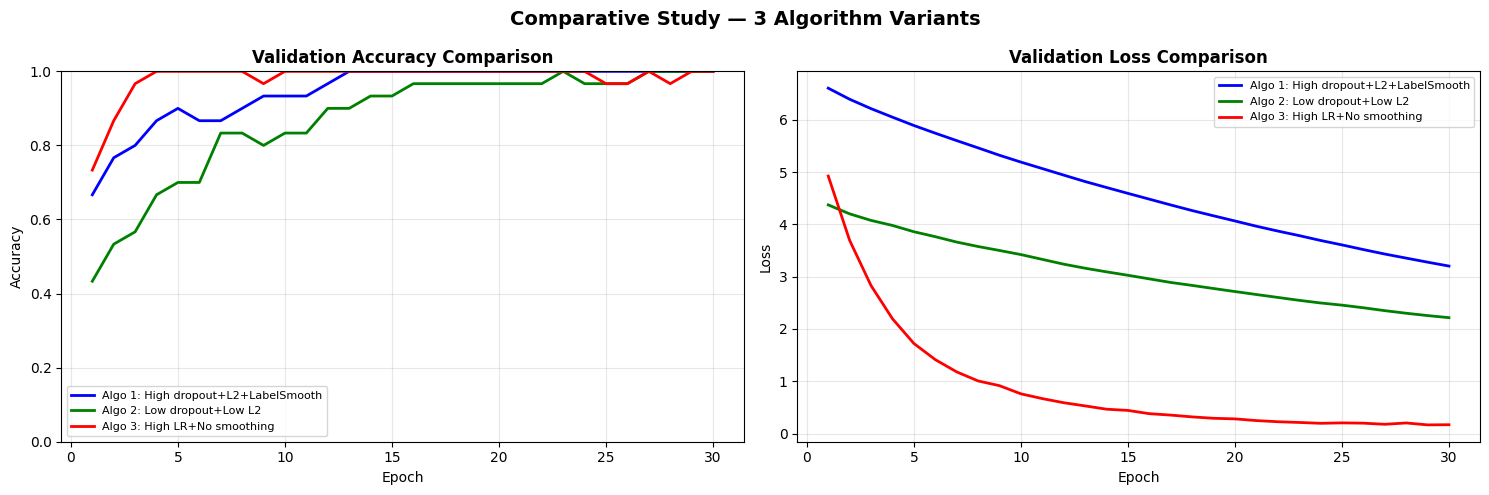

 Saved: comparative_study.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Comparative Study — 3 Algorithm Variants', fontsize=14, fontweight='bold')

for hist, label, color in [
        (history1, 'Algo 1: High dropout+L2+LabelSmooth', 'blue'),
        (history2, 'Algo 2: Low dropout+Low L2',           'green'),
        (history3, 'Algo 3: High LR+No smoothing',         'red')]:
    e = range(1, len(hist.history['val_accuracy']) + 1)
    axes[0].plot(e, hist.history['val_accuracy'], color=color, label=label, linewidth=2)
    axes[1].plot(e, hist.history['val_loss'],     color=color, label=label, linewidth=2)

axes[0].set_title('Validation Accuracy Comparison', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3); axes[0].set_ylim([0, 1])

axes[1].set_title('Validation Loss Comparison', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/comparative_study.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: comparative_study.png")

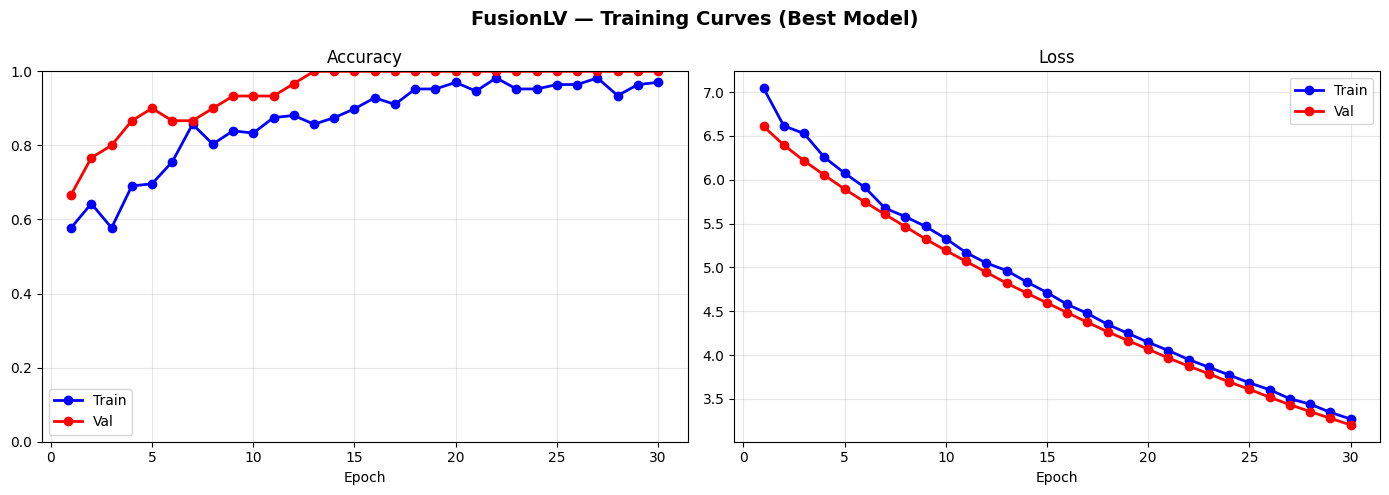

In [ ]:
epochs = range(1, len(history1.history['accuracy']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FusionLV — Training Curves (Best Model)', fontsize=14, fontweight='bold')

axes[0].plot(epochs, history1.history['accuracy'],    'b-o', label='Train', linewidth=2)
axes[0].plot(epochs, history1.history['val_accuracy'],'r-o', label='Val',   linewidth=2)
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_ylim([0,1])

axes[1].plot(epochs, history1.history['loss'],    'b-o', label='Train', linewidth=2)
axes[1].plot(epochs, history1.history['val_loss'],'r-o', label='Val',   linewidth=2)
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


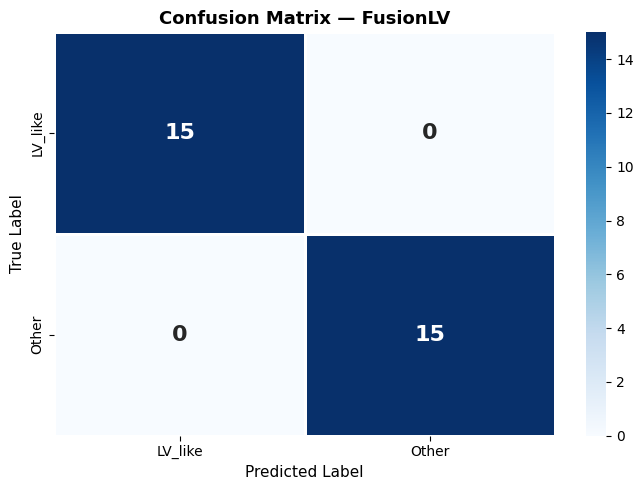


Classification Report:
              precision    recall  f1-score   support

     LV_like       1.00      1.00      1.00        15
       Other       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
y_pred      = np.argmax(model.predict(X_val), axis=1)
cm          = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=2, linecolor='white', ax=ax,
            annot_kws={"size": 16, "weight": "bold"})
ax.set_title('Confusion Matrix — FusionLV', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=CLASSES))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step


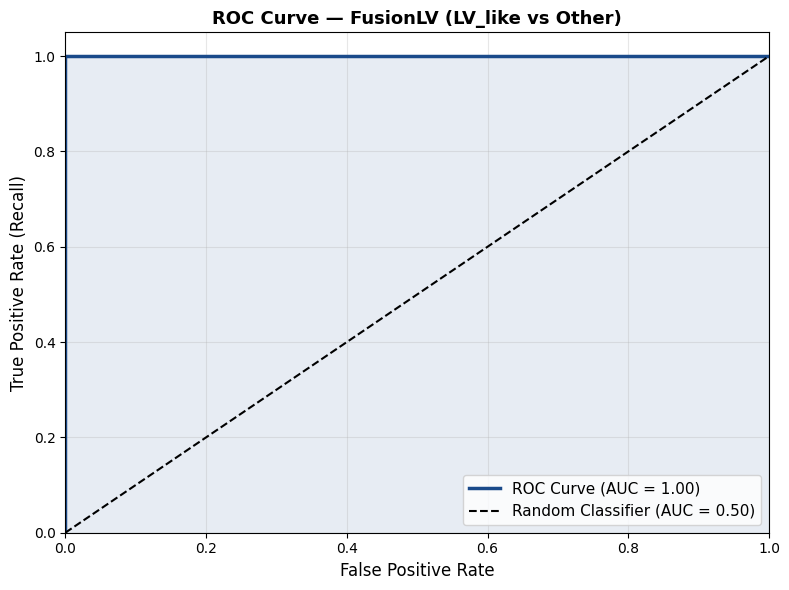

 ROC AUC = 1.0000


In [ ]:
y_val_bin  = label_binarize(y_val, classes=[0, 1])
y_prob     = model.predict(X_val)         # shape: (n, 2)

fpr, tpr, _ = roc_curve(y_val_bin.ravel(), y_prob[:, 1].ravel())
roc_auc     = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1A4A8A', lw=2.5,
         label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.fill_between(fpr, tpr, alpha=0.1, color='#1A4A8A')
plt.plot([0,1],[0,1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve — FusionLV (LV_like vs Other)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" ROC AUC = {roc_auc:.4f}")

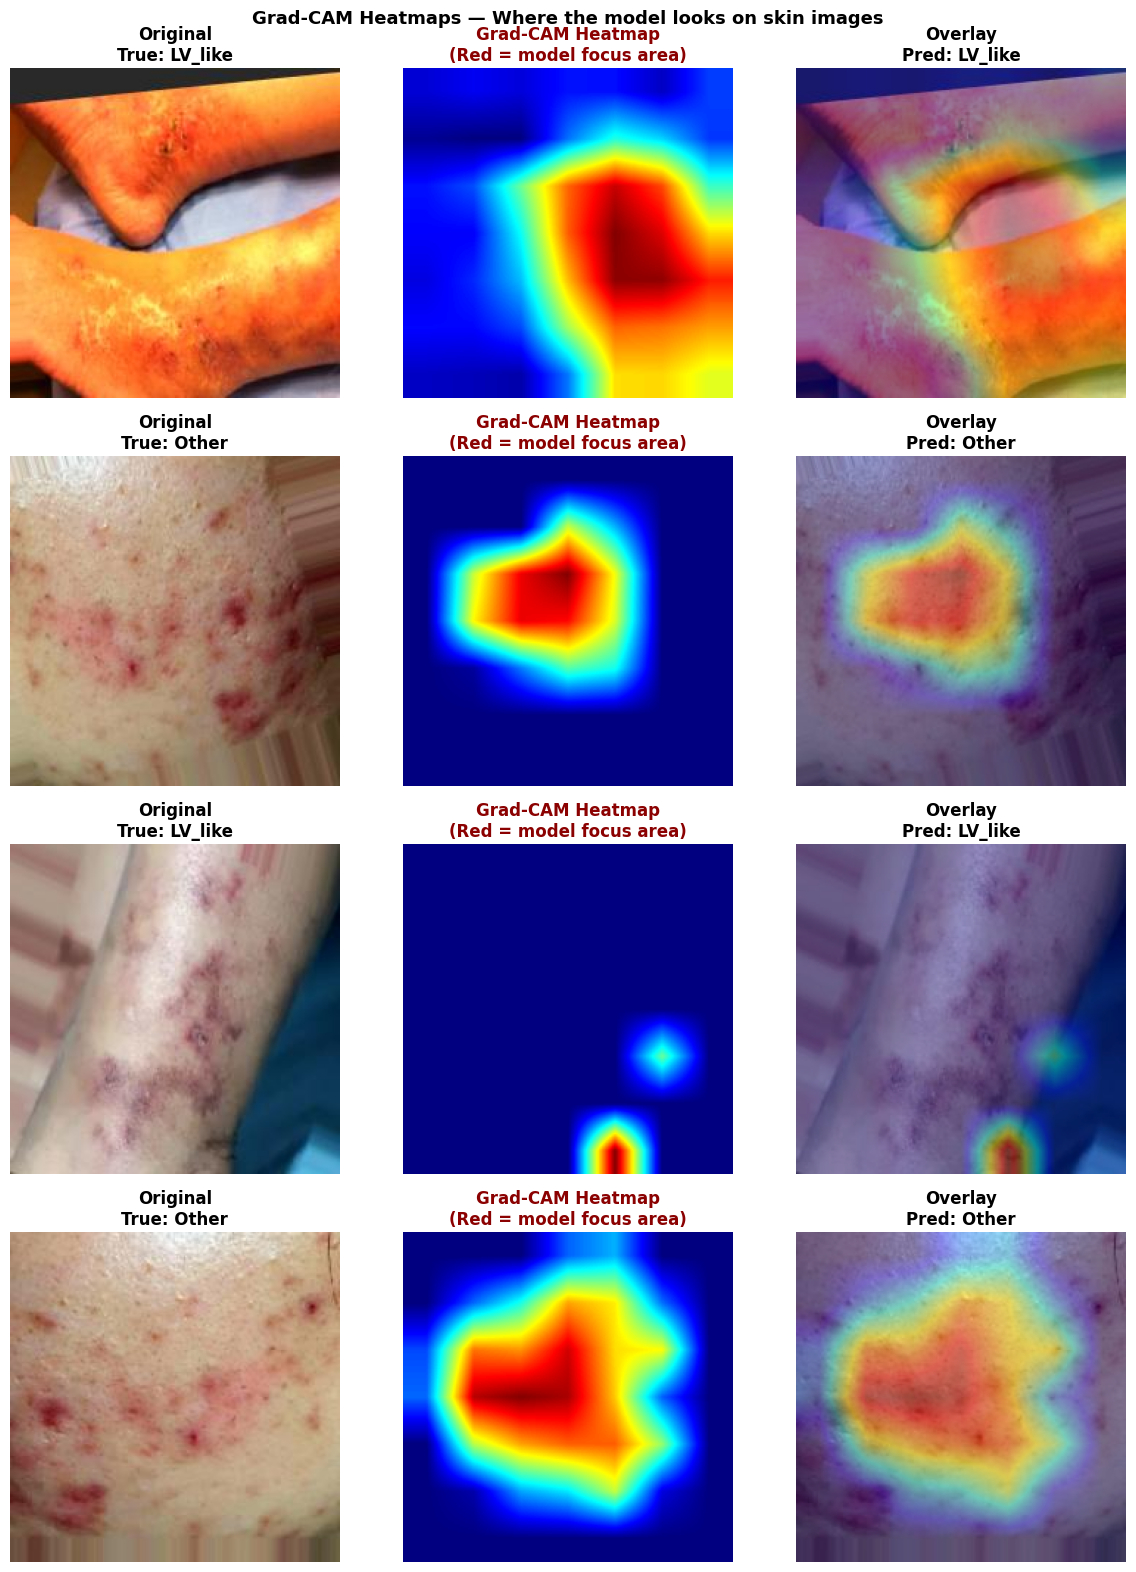

 Saved: gradcam_heatmaps.png


In [ ]:
# Grad-CAM shows WHICH part of the skin image the model focuses on
# This is what makes it medically meaningful

def make_gradcam(model, img_array, last_conv_layer='block_16_project'):
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer).output,
                 model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        pred_index  = tf.argmax(preds[0])
        class_score = preds[:, pred_index]

    grads      = tape.gradient(class_score, conv_out)
    pooled     = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out   = conv_out[0]
    heatmap    = conv_out @ pooled[..., tf.newaxis]
    heatmap    = tf.squeeze(heatmap).numpy()
    heatmap    = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
    return heatmap, CLASSES[int(pred_index)]

def overlay_gradcam(original_img, heatmap):
    h, w = original_img.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    heatmap_color   = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color   = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay         = (heatmap_color * 0.4 +
                       (original_img * 255).astype(np.uint8) * 0.6).astype(np.uint8)
    return overlay, heatmap_color

# Generate Grad-CAM for 4 validation images
n_show = min(4, len(X_val))
fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
fig.suptitle('Grad-CAM Heatmaps — Where the model looks on skin images',
             fontsize=13, fontweight='bold')

for i in range(n_show):
    img_arr     = X_val[i:i+1]
    orig_img    = X_val[i]
    true_label  = CLASSES[y_val[i]]

    heatmap, pred_label = make_gradcam(model, img_arr)
    overlay, heatmap_color = overlay_gradcam(orig_img, heatmap)

    axes[i][0].imshow(orig_img)
    axes[i][0].set_title(f'Original\nTrue: {true_label}', fontweight='bold')
    axes[i][0].axis('off')

    axes[i][1].imshow(heatmap_color)
    axes[i][1].set_title('Grad-CAM Heatmap\n(Red = model focus area)',
                         fontweight='bold', color='darkred')
    axes[i][1].axis('off')

    axes[i][2].imshow(overlay)
    axes[i][2].set_title(f'Overlay\nPred: {pred_label}', fontweight='bold')
    axes[i][2].axis('off')

plt.tight_layout()
plt.savefig('results/gradcam_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: gradcam_heatmaps.png")

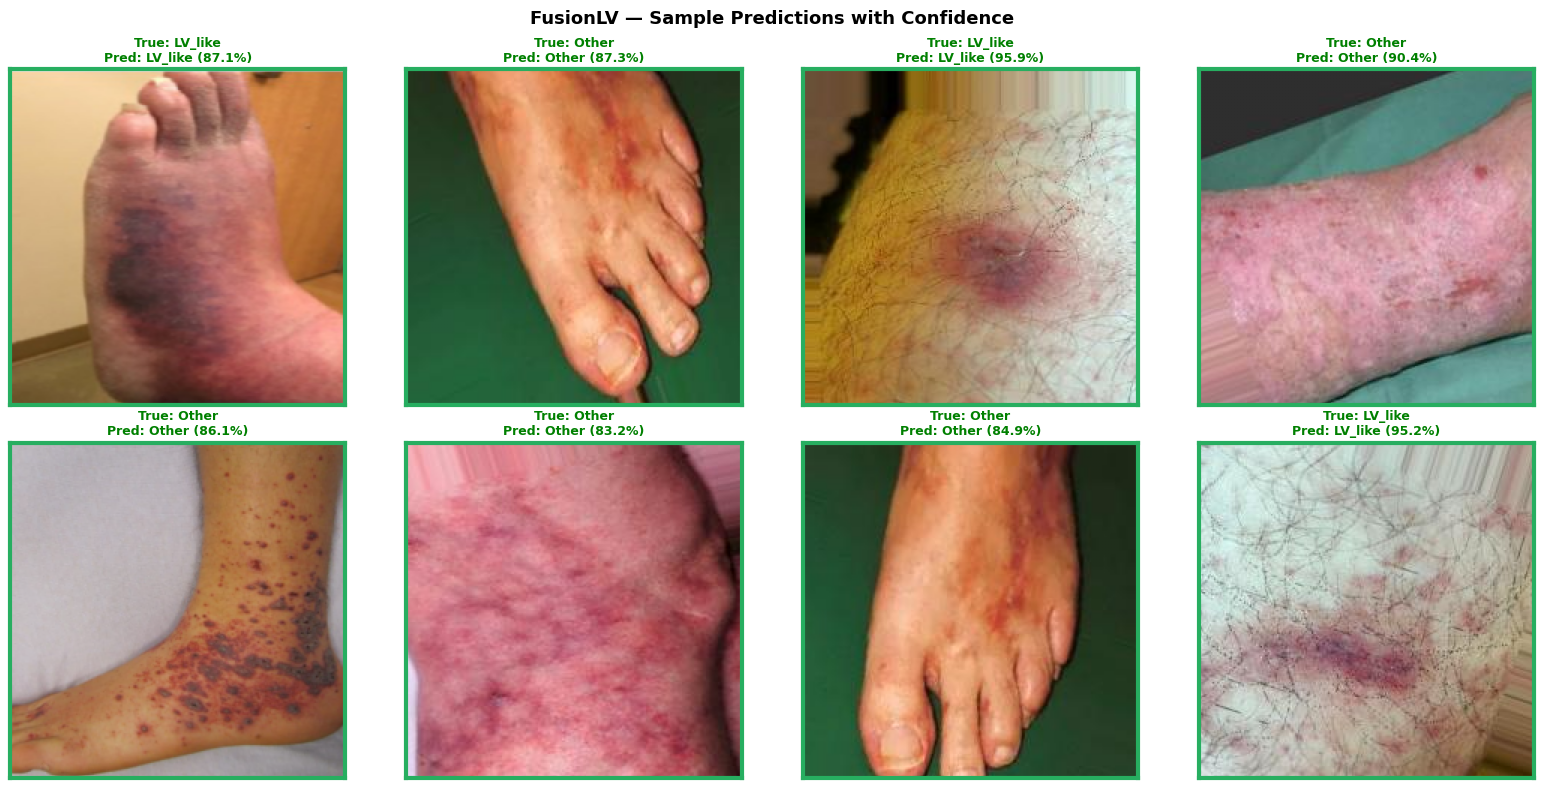

In [ ]:
n    = min(8, len(X_val))
idxs = np.random.choice(len(X_val), n, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('FusionLV — Sample Predictions with Confidence', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, idx in enumerate(idxs):
    prob      = model.predict(X_val[idx:idx+1], verbose=0)[0]
    pred_lbl  = CLASSES[np.argmax(prob)]
    true_lbl  = CLASSES[y_val[idx]]
    conf      = np.max(prob) * 100
    correct   = pred_lbl == true_lbl

    axes[i].imshow(X_val[idx])
    axes[i].set_title(f"True: {true_lbl}\nPred: {pred_lbl} ({conf:.1f}%)",
                      fontsize=9, fontweight='bold',
                      color='green' if correct else 'red')
    for s in axes[i].spines.values():
        s.set_edgecolor('#27ae60' if correct else '#e74c3c')
        s.set_linewidth(3)
    axes[i].tick_params(left=False, bottom=False,
                         labelleft=False, labelbottom=False)

plt.tight_layout()
plt.savefig('results/predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
model.save('results/fusionlv_model.h5')

val_loss, val_acc = model.evaluate(X_val, y_val_cat, verbose=0)
print("="*50)
print("   FusionLV — FINAL RESULTS")
print("="*50)
print(f"   Best Model Validation Accuracy : {val_acc*100:.2f}%")
print(f"   Validation Loss               : {val_loss:.4f}")
print(f"   ROC AUC Score                 : {roc_auc:.4f}")
print(f"   Total training images         : {len(X)}")
print("="*50)

from google.colab import files
shutil.make_archive('FusionLV_Results', 'zip', 'results')
files.download('FusionLV_Results.zip')
print(" Downloaded!")

   FusionLV — FINAL RESULTS
   Best Model Validation Accuracy : 100.00%
   Validation Loss               : 3.2037
   ROC AUC Score                 : 1.0000
   Total training images         : 198


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Downloaded!
